In [21]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# Create a dataframe with some example data
df = {
    'name': ['Alice', 'Bob', 'Charlie', 'David'],
    'years_worked': [0, 2, 4, 4],
    'salary_in_k': [30, 40, 60, 40]
}
df = pd.DataFrame(df)
# Run a linear regression model
X = df[['years_worked']]
X = sm.add_constant(X)  # Adds a constant term to the predictor
y = df['salary_in_k']
model = sm.OLS(y, X).fit()
predictions = model.predict(X)

# Print RMSE and R²
resid = model.resid
fitted = model.fittedvalues
rmse_value = np.sqrt(np.mean(resid*resid))
print(f"RMSE: {rmse_value}")
r2_value = model.rsquared
print(f"R²: {r2_value}")


RMSE: 7.0710678118654755
R²: 0.5789473684210527


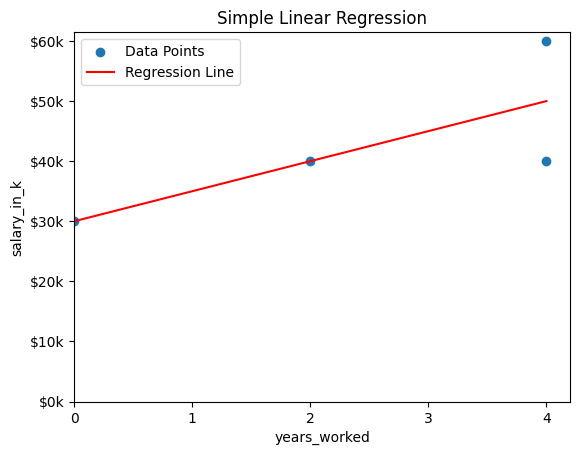

In [22]:
# Graph the df x, y, and regression line
plt.scatter(df['years_worked'], df['salary_in_k'], label='Data Points')
plt.plot(df['years_worked'], predictions, color='red', label='Regression Line')
plt.xlabel('years_worked')
plt.ylabel('salary_in_k')
# Set vertical axis to currency format
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}k".format(int(x))))
# Set years-worked to integer format with spacing of 1 year per tick
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(1))
# Set starting ticks at 0
plt.gca().set_xlim(left=0)
plt.gca().set_ylim(bottom=0)

plt.title('Simple Linear Regression')
plt.legend()
plt.show()

/var/folders/w6/p7gv5g6166vbk07p2pwdxjqr0000gp/T/ipykernel_29886/2183692971.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


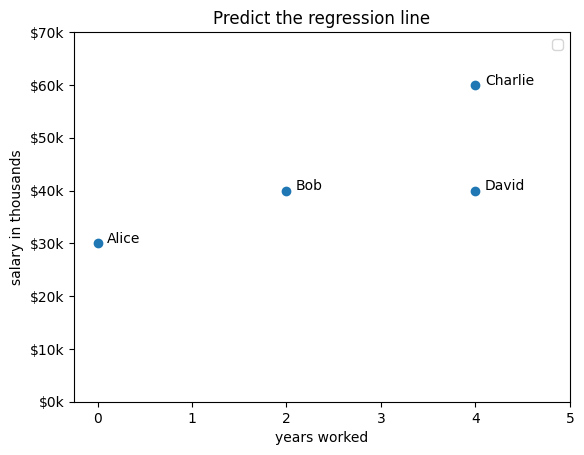

In [28]:
# Graph the df x, y, and regression line
plt.scatter(df['years_worked'], df['salary_in_k'])
plt.xlabel('years worked')
plt.ylabel('salary in thousands')
# Set vertical axis to currency format
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}k".format(int(x))))
# Set years-worked to integer format with spacing of 1 year per tick
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(1))
# Set starting ticks at 0
plt.gca().set_xlim(left=-.25, right=5)
plt.gca().set_ylim(bottom=0, top=70)

# Add label to each data point using name column
for i, row in df.iterrows():
    plt.text(row['years_worked'] + 0.1, row['salary_in_k'] + 0.1, row['name'])

plt.title('Predict the regression line')
plt.legend()
plt.show()